<a href="https://colab.research.google.com/github/ssssssshy/project/blob/main/lung_disease_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
df = pd.read_csv('lung_disease_data.csv')

In [ ]:
df.head()

,Age,Gender,Smoking Status,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.49,COPD,Therapy,14.0,Yes
1,34.0,Female,Yes,NaN,Bronchitis,Surgery,7.0,No
2,80.0,Male,Yes,1.95,COPD,NaN,4.0,Yes
3,40.0,Female,Yes,NaN,Bronchitis,Medication,1.0,No
4,43.0,Male,Yes,4.60,COPD,Surgery,NaN,Yes


In [ ]:
df.shape

(5200, 8)

In [ ]:
df[df.duplicated].shape

(91, 8)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(5109, 8)

In [ ]:
df.isnull().sum()

,0
Age,300
Gender,300
Smoking Status,300
Lung Capacity,299
Disease Type,300
Treatment Type,300
Hospital Visits,300
Recovered,300


<Axes: >

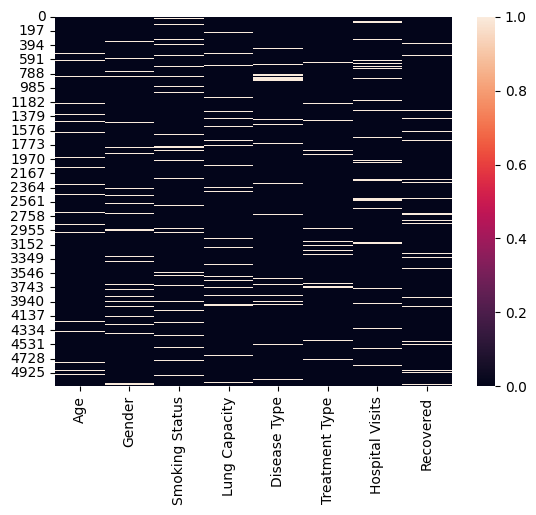

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5196
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4809 non-null   float64
 1   Gender           4809 non-null   object 
 2   Smoking Status   4809 non-null   object 
 3   Lung Capacity    4810 non-null   float64
 4   Disease Type     4809 non-null   object 
 5   Treatment Type   4809 non-null   object 
 6   Hospital Visits  4809 non-null   float64
 7   Recovered        4809 non-null   object 
dtypes: float64(3), object(5)
memory usage: 359.2+ KB


In [ ]:
g = 1
df = df[df.isnull().sum(axis = 1)<=g]

In [ ]:
df_num = df.select_dtypes('float64')

In [ ]:
df_num

,Age,Lung Capacity,Hospital Visits
0,71.0,4.49,14.0
1,34.0,NaN,7.0
2,80.0,1.95,4.0
3,40.0,NaN,1.0
4,43.0,4.60,NaN
...,...,...,...
5188,80.0,2.49,13.0
5191,29.0,3.36,6.0
5193,35.0,3.80,4.0
5194,59.0,1.05,11.0


In [ ]:
imputer = KNNImputer(n_neighbors=3,weights='uniform')
imputer.fit(df_num)
df_num = pd.DataFrame(imputer.transform(df_num),index=df_num.index,columns=df_num.columns)
df_num = df_num.round(2)
df_num.head()

,Age,Lung Capacity,Hospital Visits
0,71.0,4.49,14.00
1,34.0,2.47,7.00
2,80.0,1.95,4.00
3,40.0,5.32,1.00
4,43.0,4.60,7.67


In [ ]:
df['Age'] =  df_num['Age']
df['Lung Capacity'] = df_num['Lung Capacity']
df['Hospital Visits'] = df_num['Hospital Visits']

<Axes: >

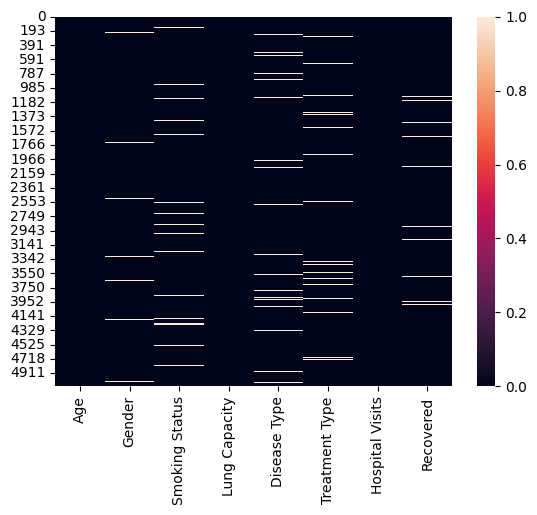

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
df.shape

(4719, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4719 entries, 0 to 5196
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4719 non-null   float64
 1   Gender           4516 non-null   object 
 2   Smoking Status   4535 non-null   object 
 3   Lung Capacity    4719 non-null   float64
 4   Disease Type     4521 non-null   object 
 5   Treatment Type   4516 non-null   object 
 6   Hospital Visits  4719 non-null   float64
 7   Recovered        4529 non-null   object 
dtypes: float64(3), object(5)
memory usage: 331.8+ KB


In [ ]:
df_num = df.select_dtypes('float64')
df_cat = pd.get_dummies(df.select_dtypes('object'),drop_first=True)

In [ ]:
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_cat), columns=df_cat.columns, index = df_cat.index)

In [ ]:
df_imputed.isnull().sum()

,0
Gender_Male,0
Smoking Status_Yes,0
Disease Type_Bronchitis,0
Disease Type_COPD,0
Disease Type_Lung Cancer,0
Disease Type_Pneumonia,0
Treatment Type_Surgery,0
Treatment Type_Therapy,0
Recovered_Yes,0


In [ ]:
df = pd.concat([df_num, df_imputed], axis=1)

In [ ]:
df.head()

,Age,Lung Capacity,Hospital Visits,Gender_Male,Smoking Status_Yes,Disease Type_Bronchitis,Disease Type_COPD,Disease Type_Lung Cancer,Disease Type_Pneumonia,Treatment Type_Surgery,Treatment Type_Therapy,Recovered_Yes
0,71.0,4.49,14.00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,34.0,2.47,7.00,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,80.0,1.95,4.00,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,40.0,5.32,1.00,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,43.0,4.60,7.67,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


<Axes: >

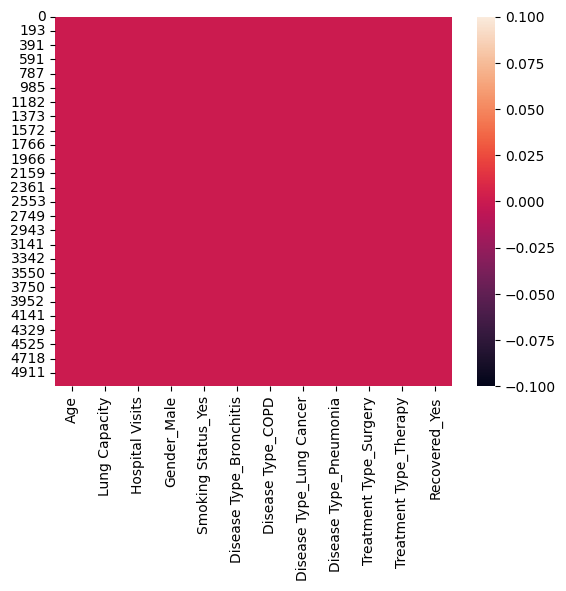

In [ ]:
sns.heatmap(df.isnull())

In [ ]:
X = df.drop('Recovered_Yes',axis=1)
y = df['Recovered_Yes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model_xgb = XGBClassifier()
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.5, 0.7],

    'n_estimators': [100, 200, 300]
}

grid_search_xgb = GridSearchCV(estimator=model_xgb, param_grid=param_grid,
                               scoring='accuracy', cv=5, n_jobs=-1)

grid_search_xgb.fit(X_train, y_train)

print("Лучшие параметры для XGBClassifier:", grid_search_xgb.best_params_)


print("Лучшая точность:", grid_search_xgb.best_score_)

Лучшие параметры для XGBClassifier: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Лучшая точность: 0.5155911612341264


In [ ]:
model_dt = DecisionTreeClassifier()
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(estimator=model_dt, param_grid=param_grid_dt,
                              scoring='accuracy', cv=5, n_jobs=-1)

grid_search_dt.fit(X_train, y_train)

print("Лучшие параметры для DecisionTreeClassifier:",
      grid_search_dt.best_params_)

print("Лучшая точность:", grid_search_dt.best_score_)

Лучшие параметры для DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая точность: 0.5222491174987393


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Предсказания для DecisionTree
y_pred_dt = grid_search_dt.predict(X_test)

# Предсказания для XGBoost
y_pred_xgb = grid_search_xgb.predict(X_test)
print("DecisionTreeClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"Precision: {precision_score(y_test, y_pred_dt)}")
print(f"Recall: {recall_score(y_test, y_pred_dt)}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_dt)}")

# Оценка XGBoost
print("\nXGBClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Precision: {precision_score(y_test, y_pred_xgb)}")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb)}")

DecisionTreeClassifier:
Accuracy: 0.4759887005649718
Precision: 0.4475920679886686
Recall: 0.47305389221556887
F1-Score: 0.45997088791848617
ROC-AUC: 0.4758317589420091

XGBClassifier:
Accuracy: 0.4915254237288136
Precision: 0.45950155763239875
Recall: 0.4416167664670659
F1-Score: 0.45038167938931295
ROC-AUC: 0.488856511575779
